In [3]:
import sys, os, pickle, random

import numpy as np
import matplotlib.pyplot as plt
from resplan_utils import *

In [4]:
# By default, we load from /mnt/data. Change DATA_PATH if needed.
DATA_PATH = 'ResPlan.pkl'

with open(DATA_PATH, 'rb') as f:
    plans = pickle.load(f)

print(f'Loaded {len(plans)} plans')
# Peek at keys of the first plan
example = plans[0]
print('Sample keys:', list(example.keys())[:20])

# Normalize common key typos (e.g., balacony -> balcony) in-place for safety
for p in plans:
    normalize_keys(p)

Loaded 17107 plans
Sample keys: ['balcony', 'bathroom', 'bedroom', 'door', 'garden', 'inner', 'parking', 'pool', 'stair', 'veranda', 'wall', 'window', 'front_door', 'unitType', 'id', 'kitchen', 'land', 'net_area', 'area', 'storage']


In [3]:
def plot_normal(plan: Dict[str, Any],
                categories: Optional[List[str]] = None,
                ax: Optional[plt.Axes] = None,
                title: Optional[str] = None,
                wall_thickness: float = 2.0) -> plt.Axes:
    """
    Plot a clean black & white floorplan sketch.
    
    - Walls/room boundaries → black
    - Background → white
    - No colors/fills
    - Looks like an architectural sketch
    """

    plan = normalize_keys(plan)

    if categories is None:
        categories = [
            "living",
            "bedroom",
            "bathroom",
            "kitchen",
            "balcony",
            "wall",
            "door",
            "window",
            "front_door"
        ]

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 8))

    # White background
    ax.set_facecolor("white")

    for key in categories:
        geom = plan.get(key)

        if geom is None:
            continue

        geoms = get_geometries(geom)

        for g in geoms:

            # -------------------------
            # Polygon / MultiPolygon
            # -------------------------
            if isinstance(g, Polygon):

                x, y = g.exterior.xy

                # Draw outer boundary
                ax.plot(
                    x, y,
                    color="black",
                    linewidth=wall_thickness
                )

                # Draw holes/interiors
                for interior in g.interiors:
                    xi, yi = interior.xy
                    ax.plot(
                        xi, yi,
                        color="black",
                        linewidth=wall_thickness
                    )

            # -------------------------
            # LineString
            # -------------------------
            elif isinstance(g, LineString):

                x, y = g.xy

                ax.plot(
                    x, y,
                    color="black",
                    linewidth=wall_thickness
                )

            # -------------------------
            # Point
            # -------------------------
            elif isinstance(g, Point):

                ax.plot(
                    g.x,
                    g.y,
                    "ko",
                    markersize=4
                )

    ax.set_aspect("equal", adjustable="box")
    ax.invert_yaxis()   # image-style orientation
    ax.axis("off")

    if title:
        ax.set_title(title)

    plt.tight_layout()

    return ax

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Class IDs
# -----------------------------
CLASS_MAP = {
    "wall": 1,
    "living": 2,
    "bedroom": 3,
    "bathroom": 4,
    "kitchen": 5,
    "balcony": 6,
    "door": 7,
    "window": 8,
    "front_door": 9,
    "garden": 10,
    "parking": 11,
    "pool": 12,
    "stair": 13,
    "veranda": 14,
    "storage": 15,
}

PATH = "/opt/dlami/nvme/"

# -----------------------------
# Output folders
# -----------------------------
IMAGE_DIR = PATH + "mitunet_dataset_1/images"
MASK_DIR  = PATH + "mitunet_dataset_1/masks"

os.makedirs(IMAGE_DIR, exist_ok=True)
os.makedirs(MASK_DIR, exist_ok=True)

# -----------------------------
# Canvas size
# -----------------------------
MASK_SIZE = (256, 256)

def normalize_geom(g, bounds, size=256):
    minx, miny, maxx, maxy = bounds
    sx = (size - 1) / (maxx - minx)
    sy = (size - 1) / (maxy - miny)

    return affinity.translate(
        affinity.scale(g, xfact=sx, yfact=sy, origin=(minx, miny)),
        xoff=-minx * sx,
        yoff=-miny * sy
    )

# -----------------------------
# Generate dataset
# -----------------------------
for idx, plan in enumerate(plans[:100]):

    plan = normalize_keys(plan)

    # compute global bounds once per plan
    minx, miny, maxx, maxy = plan["inner"].bounds
    bounds = (minx, miny, maxx, maxy)

    plan_norm = {}

    for k, v in plan.items():
        if v is None:
            continue
        # plan_norm[k] = normalize_geom(v, bounds, size=MASK_SIZE[0])
        plan_norm[k] = v  # --- IGNORE ---

    # =====================================
    # SAVE IMAGE
    # =====================================
    fig, ax = plt.subplots(figsize=(8, 8))

    plot_normal(
        # plan,
        plan_norm,
        ax=ax,
        title=None
    )

    # ax.set_xlim(0, MASK_SIZE[1])
    # ax.set_ylim(MASK_SIZE[0], 0)

    ax.axis("off")

    fig.canvas.draw()

    image = np.frombuffer(
        fig.canvas.buffer_rgba(),
        dtype=np.uint8
    )

    image = image.reshape(
        fig.canvas.get_width_height()[::-1] + (4,)
    )

    image = cv2.cvtColor(image, cv2.COLOR_RGBA2GRAY)

    image = cv2.resize(
        image,
        (MASK_SIZE[1], MASK_SIZE[0]),
        interpolation=cv2.INTER_NEAREST
    )

    image_path = os.path.join(
        IMAGE_DIR,
        f"{idx:05d}.png"
    )

    cv2.imwrite(image_path, image)

    plt.close(fig)

    # =====================================
    # CREATE SEGMENTATION MASK
    # =====================================
    mask = np.zeros(MASK_SIZE, dtype=np.uint8)

    for cls_name, cls_id in CLASS_MAP.items():

        geom = plan_norm.get(cls_name)

        if geom is None:
            continue

        binary_mask = geometry_to_mask(
            geom,
            shape=MASK_SIZE
        )

        mask[binary_mask > 0] = cls_id

    # =====================================
    # SAVE MASK
    # =====================================
    mask_path = os.path.join(
        MASK_DIR,
        f"{idx:05d}.png"
    )

    cv2.imwrite(mask_path, mask)

print(f"Saved {len(plans[:100])} images and masks.")

Saved 100 images and masks.


In [27]:
import numpy as np
import cv2
import random
import matplotlib.pyplot as plt

from shapely.geometry import Polygon, LineString, Point, MultiPolygon, MultiLineString, GeometryCollection
from shapely.geometry.base import BaseGeometry
from shapely import affinity, wkt

# -----------------------------
# CLASS MAP
# -----------------------------
CLASS_MAP = {
    "wall": 1,
    "living": 2,
    "bedroom": 3,
    "bathroom": 4,
    "kitchen": 5,
    "balcony": 6,
    "door": 7,
    "window": 8,
    "front_door": 9,
    "garden": 10,
    "parking": 11,
    "pool": 12,
    "stair": 13,
    "veranda": 14,
    "storage": 15,
}

# -----------------------------
# SAFE GEOMETRY PARSER
# -----------------------------
def _to_geom(g):
    if g is None:
        return None
    if isinstance(g, BaseGeometry):
        return g
    if isinstance(g, str):
        try:
            return wkt.loads(g)
        except:
            return None
    return None

# -----------------------------
# NORMALIZATION (WORLD → PIXEL)
# -----------------------------
def normalize_plan_to_canvas(plan, shape=(256, 256)):

    H, W = shape

    inner = _to_geom(plan.get("inner"))

    if inner is None:
        for v in plan.values():
            inner = _to_geom(v)
            if inner is not None:
                break

    if inner is None:
        raise ValueError("No valid geometry found")

    minx, miny, maxx, maxy = inner.bounds

    sx = (W - 1) / (maxx - minx + 1e-9)
    sy = (H - 1) / (maxy - miny + 1e-9)

    norm = {}

    for k, geom in plan.items():

        geom = _to_geom(geom)
        if geom is None:
            continue

        g = affinity.scale(geom, xfact=sx, yfact=sy, origin=(minx, miny))
        g = affinity.translate(g, xoff=-minx * sx, yoff=-miny * sy)

        norm[k] = g

    return norm

# -----------------------------
# MASK GENERATION
# -----------------------------
def resplan_to_mask(plan, class_map, shape=(256, 256)):

    H, W = shape
    mask = np.zeros((H, W), dtype=np.uint8)

    for cls_name, cls_id in class_map.items():

        geom = plan.get(cls_name)
        geom = _to_geom(geom)

        if geom is None:
            continue

        geoms = geom.geoms if hasattr(geom, "geoms") else [geom]

        for g in geoms:

            if g is None or g.is_empty:
                continue

            # POLYGON
            if isinstance(g, Polygon):
                x, y = g.exterior.coords.xy
                pts = np.stack([x, y], axis=-1).astype(np.int32)
                cv2.fillPoly(mask, [pts], cls_id)

                for interior in g.interiors:
                    xi, yi = interior.coords.xy
                    hole = np.stack([xi, yi], axis=-1).astype(np.int32)
                    cv2.fillPoly(mask, [hole], 0)

            # LINE
            elif isinstance(g, LineString):
                x, y = g.coords.xy
                pts = np.stack([x, y], axis=-1).astype(np.int32)
                cv2.polylines(mask, [pts], False, cls_id, 1)

            # POINT
            elif isinstance(g, Point):
                x, y = int(g.x), int(g.y)
                if 0 <= x < W and 0 <= y < H:
                    mask[y, x] = cls_id

    return mask

# -----------------------------
# RASTER VISUALIZATION (PLAN)
# -----------------------------
def render_plan(plan, shape=(256, 256)):

    H, W = shape
    img = np.ones((H, W), dtype=np.uint8) * 255

    for cls_name, cls_id in CLASS_MAP.items():

        geom = plan.get(cls_name)
        geom = _to_geom(geom)

        if geom is None:
            continue

        geoms = geom.geoms if hasattr(geom, "geoms") else [geom]

        for g in geoms:

            if g is None or g.is_empty:
                continue

            if isinstance(g, Polygon):
                x, y = g.exterior.coords.xy
                pts = np.stack([x, y], axis=-1).astype(np.int32)
                cv2.polylines(img, [pts], True, 0, 1)

            elif isinstance(g, LineString):
                x, y = g.coords.xy
                pts = np.stack([x, y], axis=-1).astype(np.int32)
                cv2.polylines(img, [pts], False, 0, 1)

            elif isinstance(g, Point):
                cv2.circle(img, (int(g.x), int(g.y)), 1, 0, -1)

    return img

In [29]:
IMAGE_DIR = PATH + "mitunet_dataset/images"
MASK_DIR  = PATH + "mitunet_dataset/masks"

os.makedirs(IMAGE_DIR, exist_ok=True)
os.makedirs(MASK_DIR, exist_ok=True)

# save the images and masks
for idx, plan in enumerate(plans[:100]):
    # STEP 1: normalize
    plan_norm = normalize_plan_to_canvas(plan, shape=(256, 256))

    # STEP 2: mask
    mask = resplan_to_mask(plan_norm, CLASS_MAP, shape=(256, 256))

    # STEP 3: render image
    img = render_plan(plan_norm, shape=(256, 256))

    # # -----------------------------
    # # PLOT
    # # -----------------------------
    # fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    # axes[0].imshow(img, cmap="gray")
    # axes[0].set_title("Floorplan")
    # axes[0].axis("off")

    # axes[1].imshow(mask, cmap="nipy_spectral")
    # axes[1].set_title("Segmentation Mask")
    # axes[1].axis("off")

    # plt.tight_layout()
    # plt.show()

    # save image and mask
    img_path = os.path.join(IMAGE_DIR, f"{idx:05d}.png")
    mask_path = os.path.join(MASK_DIR, f"{idx:05d}.png")
    cv2.imwrite(img_path, img)
    cv2.imwrite(mask_path, mask)
    print(f"\r Saved {img_path} and {mask_path}")


 Saved /opt/dlami/nvme/mitunet_dataset/images/00000.png and /opt/dlami/nvme/mitunet_dataset/masks/00000.png
 Saved /opt/dlami/nvme/mitunet_dataset/images/00001.png and /opt/dlami/nvme/mitunet_dataset/masks/00001.png
 Saved /opt/dlami/nvme/mitunet_dataset/images/00002.png and /opt/dlami/nvme/mitunet_dataset/masks/00002.png
 Saved /opt/dlami/nvme/mitunet_dataset/images/00003.png and /opt/dlami/nvme/mitunet_dataset/masks/00003.png
 Saved /opt/dlami/nvme/mitunet_dataset/images/00004.png and /opt/dlami/nvme/mitunet_dataset/masks/00004.png
 Saved /opt/dlami/nvme/mitunet_dataset/images/00005.png and /opt/dlami/nvme/mitunet_dataset/masks/00005.png
 Saved /opt/dlami/nvme/mitunet_dataset/images/00006.png and /opt/dlami/nvme/mitunet_dataset/masks/00006.png
 Saved /opt/dlami/nvme/mitunet_dataset/images/00007.png and /opt/dlami/nvme/mitunet_dataset/masks/00007.png
 Saved /opt/dlami/nvme/mitunet_dataset/images/00008.png and /opt/dlami/nvme/mitunet_dataset/masks/00008.png
 Saved /opt/dlami/nvme/mitun

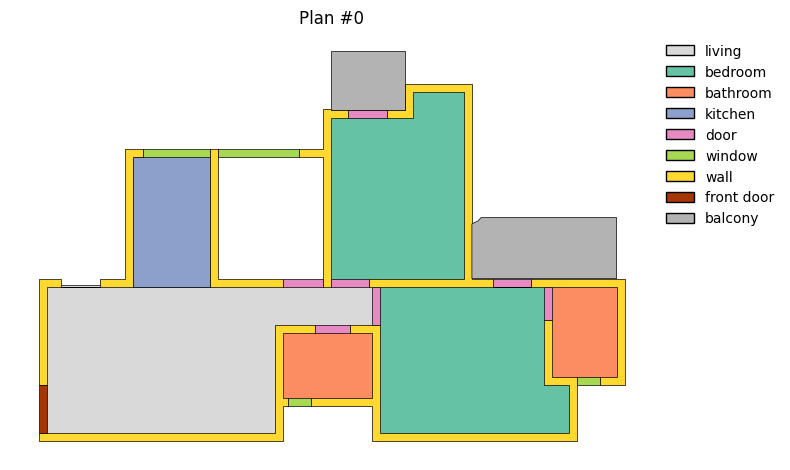

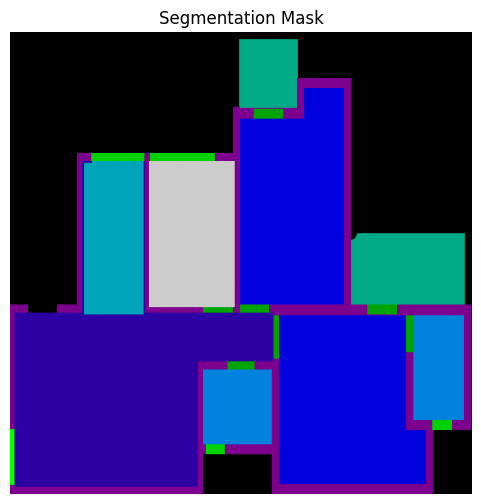

In [37]:
import numpy as np
import cv2
from shapely.geometry import Polygon, MultiPolygon

CLASS_MAP = {
    "wall": 1,
    "living": 2,
    "bedroom": 3,
    "bathroom": 4,
    "kitchen": 5,
    "balcony": 6,
    "door": 7,
    "window": 8,
    "front_door": 9,
    "garden": 10,
    "parking": 11,
    "pool": 12,
    "stair": 13,
    "veranda": 14,
    "storage": 15,
}

def draw_geom(geom, mask, cls):
    if geom is None:
        return

    if isinstance(geom, Polygon):
        geoms = [geom]
    elif isinstance(geom, MultiPolygon):
        geoms = geom.geoms
    else:
        return

    for g in geoms:
        pts = np.array(g.exterior.coords, dtype=np.int32)
        cv2.fillPoly(mask, [pts], cls)

def get_bounds(plan):
    all_geoms = []

    for g in plan.values():
        if isinstance(g, (Polygon, MultiPolygon)):
            if isinstance(g, Polygon):
                all_geoms.append(g)
            else:
                all_geoms.extend(g.geoms)

    union = unary_union(all_geoms)
    return union.bounds  # minx, miny, maxx, maxy

def create_mask(plan, H=512, W=512):
    mask = np.zeros((H, W), dtype=np.uint8)

    minx, miny, maxx, maxy = get_bounds(plan)

    scale_x = (W - 1) / (maxx - minx)
    scale_y = (H - 1) / (maxy - miny)

    for label, geom in plan.items():
        if label not in CLASS_MAP:
            continue

        cls = CLASS_MAP[label]

        geoms = []
        if isinstance(geom, Polygon):
            geoms = [geom]
        elif isinstance(geom, MultiPolygon):
            geoms = geom.geoms

        for g in geoms:
            coords = np.array(g.exterior.coords)

            # NORMALIZE HERE (this is what you were missing)
            coords[:, 0] = (coords[:, 0] - minx) * scale_x
            coords[:, 1] = (coords[:, 1] - miny) * scale_y

            pts = coords.astype(np.int32)
            cv2.fillPoly(mask, [pts], cls)

    # reverse the mask up and down
    mask = np.flipud(mask)
    return mask

idx = 0
plan = plans[idx]

ax = plot_plan(plan, title=f'Plan #{idx}')
plt.show()

mask = create_mask(plan)

# plot
plt.figure(figsize=(6, 6))
plt.imshow(mask, cmap="nipy_spectral")
plt.title("Segmentation Mask")
plt.axis("off")
plt.show()

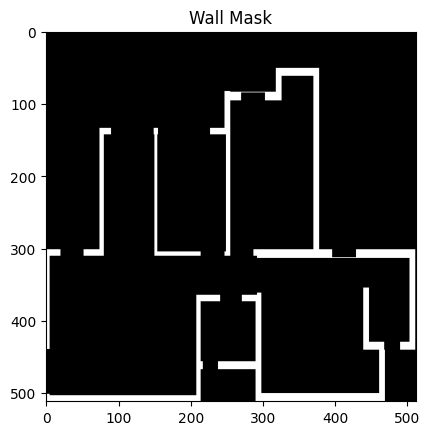

In [39]:
import numpy as np
import matplotlib.pyplot as plt

# assuming mask is already created
wall_mask = (mask == CLASS_MAP["wall"]).astype(np.uint8)

plt.imshow(wall_mask, cmap="gray")
plt.title("Wall Mask")
# plt.axis("off")
plt.show()